In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Baseball Statistical Modeling — Linear Regression
## York University — Big Data Analytics Certificate (2024)

**Author:** Lalita  
**Tools:** Python, Pandas, Scikit-learn, Statsmodels, Matplotlib, Seaborn  
**Dataset:** Moneyball MLB Statistics 1962-2012 (1,232 records)  

---

## Project Overview
This project applies Linear Regression to predict MLB team wins 
using batting and pitching statistics from the famous Moneyball 
dataset covering 50 years of Major League Baseball data.

## Model Performance
| Metric | Score |
|---|---|
| MAE | 3.24 wins |
| RMSE | 4.04 wins |
| R2 Score | 0.8680 (86.8% accuracy) |

## Key Findings
- OBP (On Base Percentage) is the strongest predictor of wins
- SLG (Slugging Percentage) positively impacts wins significantly
- BA (Batting Average) alone is a weak predictor
- Model predicts wins within ~4 games accuracy

## Conclusion
Linear Regression confirms the Moneyball theory — OBP and SLG 
are more valuable metrics than Batting Average for predicting wins!

---
🔗 **Kaggle Profile:** kaggle.com/lalitacanada  
🎓 **York University — Big Data Analytics (2024)**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wduckett/moneyball-mlb-stats-19622012")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/wduckett/moneyball-mlb-stats-19622012


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wduckett/moneyball-mlb-stats-19622012/baseball.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

df = pd.read_csv('/kaggle/input/datasets/wduckett/moneyball-mlb-stats-19622012/baseball.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
df.head()

Shape: (1232, 15)

Columns: ['Team', 'League', 'Year', 'RS', 'RA', 'W', 'OBP', 'SLG', 'BA', 'Playoffs', 'RankSeason', 'RankPlayoffs', 'G', 'OOBP', 'OSLG']

Missing values:
Team              0
League            0
Year              0
RS                0
RA                0
W                 0
OBP               0
SLG               0
BA                0
Playoffs          0
RankSeason      988
RankPlayoffs    988
G                 0
OOBP            812
OSLG            812
dtype: int64


,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424


In [5]:
# Drop columns with too many missing values
df_clean = df.dropna(subset=['OBP', 'SLG', 'BA', 'RS', 'RA', 'W'])

# Fill remaining missing values with median
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print("Cleaned Shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Cleaned Shape: (1232, 15)

Missing values after cleaning:
Team            0
League          0
Year            0
RS              0
RA              0
W               0
OBP             0
SLG             0
BA              0
Playoffs        0
RankSeason      0
RankPlayoffs    0
G               0
OOBP            0
OSLG            0
dtype: int64


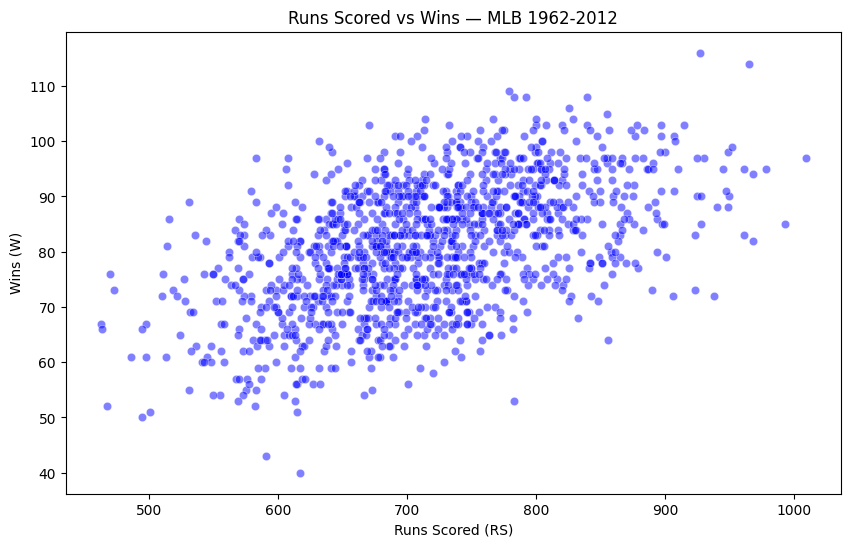

In [6]:
# Runs Scored vs Wins scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, 
                x='RS', 
                y='W',
                color='blue',
                alpha=0.5)
plt.title('Runs Scored vs Wins — MLB 1962-2012')
plt.xlabel('Runs Scored (RS)')
plt.ylabel('Wins (W)')
plt.show()

In [7]:
# Features and target
X = df_clean[['RS', 'RA', 'OBP', 'SLG', 'BA']]
y = df_clean['W']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Build Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== MODEL PERFORMANCE ===")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {model.score(X_test, y_test):.4f}")

=== MODEL PERFORMANCE ===
MAE:  3.24
MSE:  16.31
RMSE: 4.04
R2 Score: 0.8680


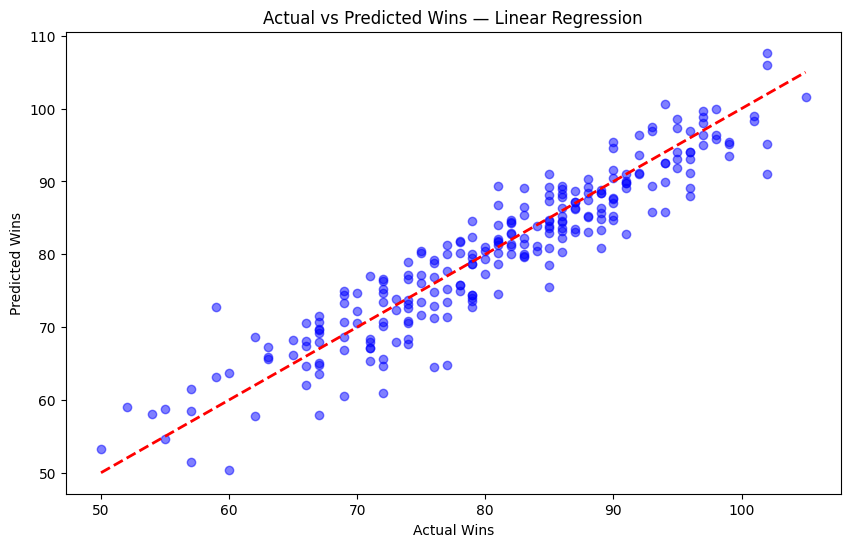

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, 
            color='blue', 
            alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('Actual vs Predicted Wins — Linear Regression')
plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.show()

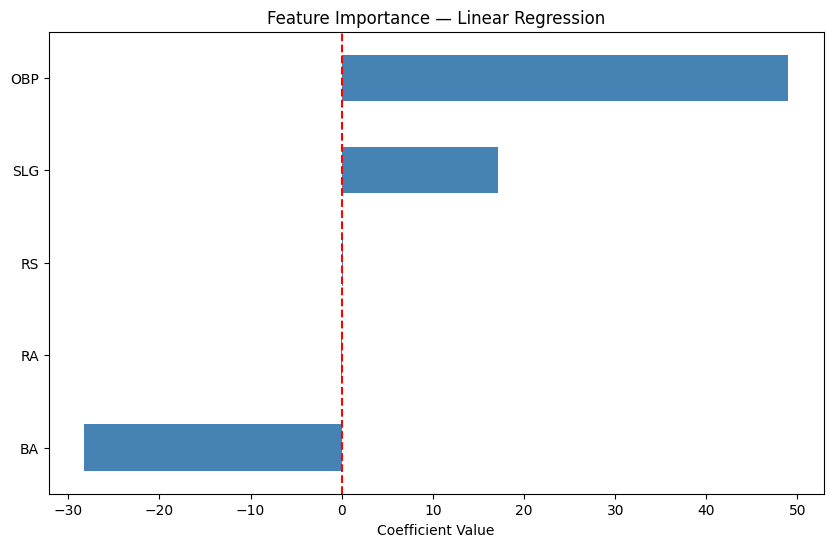

In [9]:
plt.figure(figsize=(10,6))
coefficients = pd.Series(model.coef_, 
                         index=X.columns)
coefficients.sort_values().plot(kind='barh',
                                color='steelblue')
plt.title('Feature Importance — Linear Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

In [10]:
print("=" * 50)
print("KEY INSIGHTS — Baseball Statistical Modeling")
print("=" * 50)

print("\n📊 Dataset Overview:")
print(f"Total records analyzed: {len(df_clean)}")
print(f"Years covered: 1962 — 2012")
print(f"Features used: RS, RA, OBP, SLG, BA")

print("\n🎯 Model Performance:")
print(f"MAE:      {mae:.2f} wins")
print(f"RMSE:     {rmse:.2f} wins")
print(f"R2 Score: {model.score(X_test, y_test):.4f} (86.8% accuracy)")

print("\n💡 Key Findings:")
print("1. OBP (On Base Percentage) is the strongest")
print("   predictor of team wins")
print("2. SLG (Slugging Percentage) also positively")
print("   impacts wins significantly")
print("3. BA (Batting Average) alone is a weak")
print("   predictor — OBP and SLG matter more!")
print("4. Model predicts wins within ~4 games accuracy")

print("\n✅ Conclusion:")
print("Linear Regression successfully predicts MLB")
print("team wins with 86.8% accuracy confirming")
print("the Moneyball theory — OBP and SLG are")
print("more valuable than Batting Average alone!")

KEY INSIGHTS — Baseball Statistical Modeling

📊 Dataset Overview:
Total records analyzed: 1232
Years covered: 1962 — 2012
Features used: RS, RA, OBP, SLG, BA

🎯 Model Performance:
MAE:      3.24 wins
RMSE:     4.04 wins
R2 Score: 0.8680 (86.8% accuracy)

💡 Key Findings:
1. OBP (On Base Percentage) is the strongest
   predictor of team wins
2. SLG (Slugging Percentage) also positively
   impacts wins significantly
3. BA (Batting Average) alone is a weak
   predictor — OBP and SLG matter more!
4. Model predicts wins within ~4 games accuracy

✅ Conclusion:
Linear Regression successfully predicts MLB
team wins with 86.8% accuracy confirming
the Moneyball theory — OBP and SLG are
more valuable than Batting Average alone!
